# AI Labor Market Analysis & Predictive Modeling
**Dataset:** `ai_jobs_market_2025_2026.csv` — 1,500 job postings, 25 features

**Contents:**
1. Data Cleaning & Preparation
2. Exploratory Data Analysis (EDA)
3. Principal Component Analysis (PCA)
4. K-Means Clustering (AI Engineering & Governance)
5. KNN Regression - Salary Estimation

In [1]:
# Core imports 
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.stats import zscore
from itertools import combinations
from collections import Counter, defaultdict

# Global style
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
RANDOM_STATE = 42
print('Libraries loaded')

Libraries loaded


## 1. DATA CLEANING & PREPARATION

In [2]:
# Load 
df_raw = pd.read_csv('csv_ai_jobs_market_2025_2026.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(5)

Shape: (1500, 25)


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [3]:
# Missing values 
if not df_raw.isnull().values.any():
    print('No missing values found in the dataset.')
else:
    print('Missing values found in the dataset.')

No missing values found in the dataset.


In [4]:
# Data types & basic formatting
df = df_raw.copy()

# Ensure correct dtypes
num_cols = ['annual_salary_usd', 'salary_min_usd', 'salary_max_usd',
            'years_of_experience', 'ai_salary_premium_pct',
            'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10']
cat_cols = ['job_title', 'job_category', 'experience_level', 'education_required',
            'city', 'country', 'remote_work', 'company_size', 'industry', 'salary_tier']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in cat_cols:
    df[col] = df[col].astype('category')

# Parse skills into Python lists
df['skills_list'] = df['required_skills'].str.split('|')
df['skills_list'] = df['skills_list'].apply(lambda x: [s.strip() for s in x] if isinstance(x, list) else [])
df['n_skills'] = df['skills_list'].apply(len)

print(df.dtypes)
print(f'\nSkill list sample: {df["skills_list"].iloc[0]}')

job_id                     object
job_title                category
job_category             category
experience_level         category
years_of_experience         int64
education_required       category
annual_salary_usd         float64
salary_min_usd              int64
salary_max_usd              int64
city                     category
country                  category
remote_work              category
company_size             category
industry                 category
required_skills            object
ai_salary_premium_pct     float64
demand_score                int64
demand_growth_yoy_pct     float64
benefits_score_10         float64
posting_year                int64
posting_month               int64
is_senior                   int64
is_remote_friendly          int64
is_llm_role                 int64
salary_tier              category
skills_list                object
n_skills                    int64
dtype: object

Skill list sample: ['APIs', 'Planning Systems', 'Python', 'Cloud', 

Outliers detected per column (k=3 IQR):
  annual_salary_usd: 0
  years_of_experience: 0
  demand_score: 0
  ai_salary_premium_pct: 0
  benefits_score_10: 0


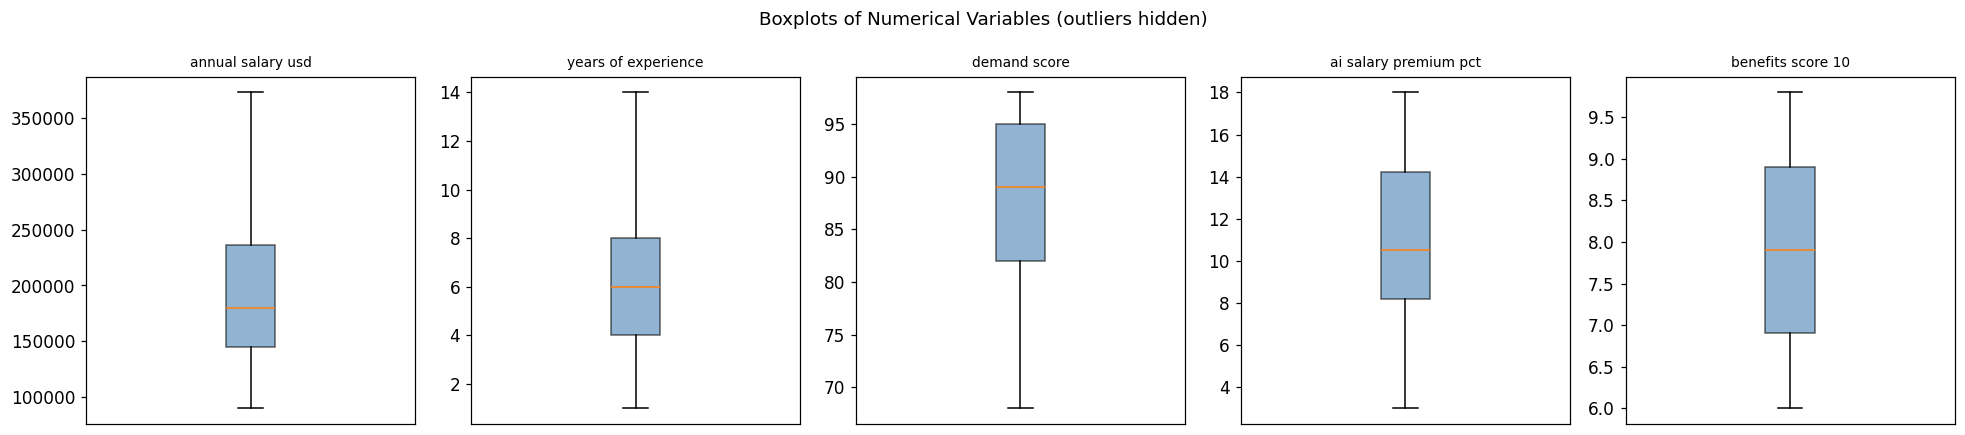


No extreme anomalies requiring deletion. Data is analysis-ready.


In [5]:
# Outlier detection (IQR method)
def flag_outliers_iqr(series, k=3.0):
    """Return boolean mask of outliers using k*IQR rule."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - k * IQR) | (series > Q3 + k * IQR)

outlier_report = {}
for col in ['annual_salary_usd', 'years_of_experience', 'demand_score',
            'ai_salary_premium_pct', 'benefits_score_10']:
    mask = flag_outliers_iqr(df[col])
    outlier_report[col] = mask.sum()

print('Outliers detected per column (k=3 IQR):')
for col, n in outlier_report.items():
    print(f'  {col}: {n}')

# Visualise distributions + outlier bounds
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
cols_to_plot = ['annual_salary_usd', 'years_of_experience', 'demand_score',
                'ai_salary_premium_pct', 'benefits_score_10']
for ax, col in zip(axes, cols_to_plot):
    # Se añade únicamente showfliers=False para esconder los círculos
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.set_xticks([])
fig.suptitle('Boxplots of Numerical Variables (outliers hidden)', fontsize=12)
plt.tight_layout()
plt.show()

# Decision: dataset is synthetic/curated — no rows dropped, outliers noted only
print('\nNo extreme anomalies requiring deletion. Data is analysis-ready.')

## 2. EXPLORATORY DATA ANALYSIS (EDA)

In [6]:
# 2.1 Descriptive statistics
num_cols = [
    'annual_salary_usd', 'salary_min_usd', 'salary_max_usd', 
    'years_of_experience', 'ai_salary_premium_pct', 
    'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10'
]

summary = df[num_cols].describe(percentiles=[.10, .25, .50, .75, .90]).T
summary['variance'] = df[num_cols].var()

display(summary.round(2))

,count,mean,std,min,10%,25%,50%,75%,90%,max,variance
annual_salary_usd,1500.0,194892.00,66506.82,90000.0,120900.0,144750.00,180000.0,236250.0,297100.00,384000.0,4.423157e+09
salary_min_usd,1500.0,135448.67,24448.95,90000.0,100000.0,120000.00,140000.0,155000.0,160000.00,180000.0,5.977512e+08
salary_max_usd,1500.0,257537.33,39852.82,180000.0,200000.0,218000.00,270000.0,290000.0,300000.00,320000.0,1.588247e+09
years_of_experience,1500.0,6.22,2.68,1.0,3.0,4.00,6.0,8.0,10.00,15.0,7.160000e+00
ai_salary_premium_pct,1500.0,10.86,4.03,3.0,5.0,8.20,10.5,14.2,16.60,18.0,1.624000e+01
demand_score,1500.0,87.52,8.03,68.0,76.0,82.00,89.0,95.0,96.00,98.0,6.442000e+01
demand_growth_yoy_pct,1500.0,31.12,22.05,5.0,9.1,15.38,23.4,42.7,69.81,87.8,4.860400e+02
benefits_score_10,1500.0,7.90,1.10,6.0,6.4,6.90,7.9,8.9,9.40,9.8,1.220000e+00


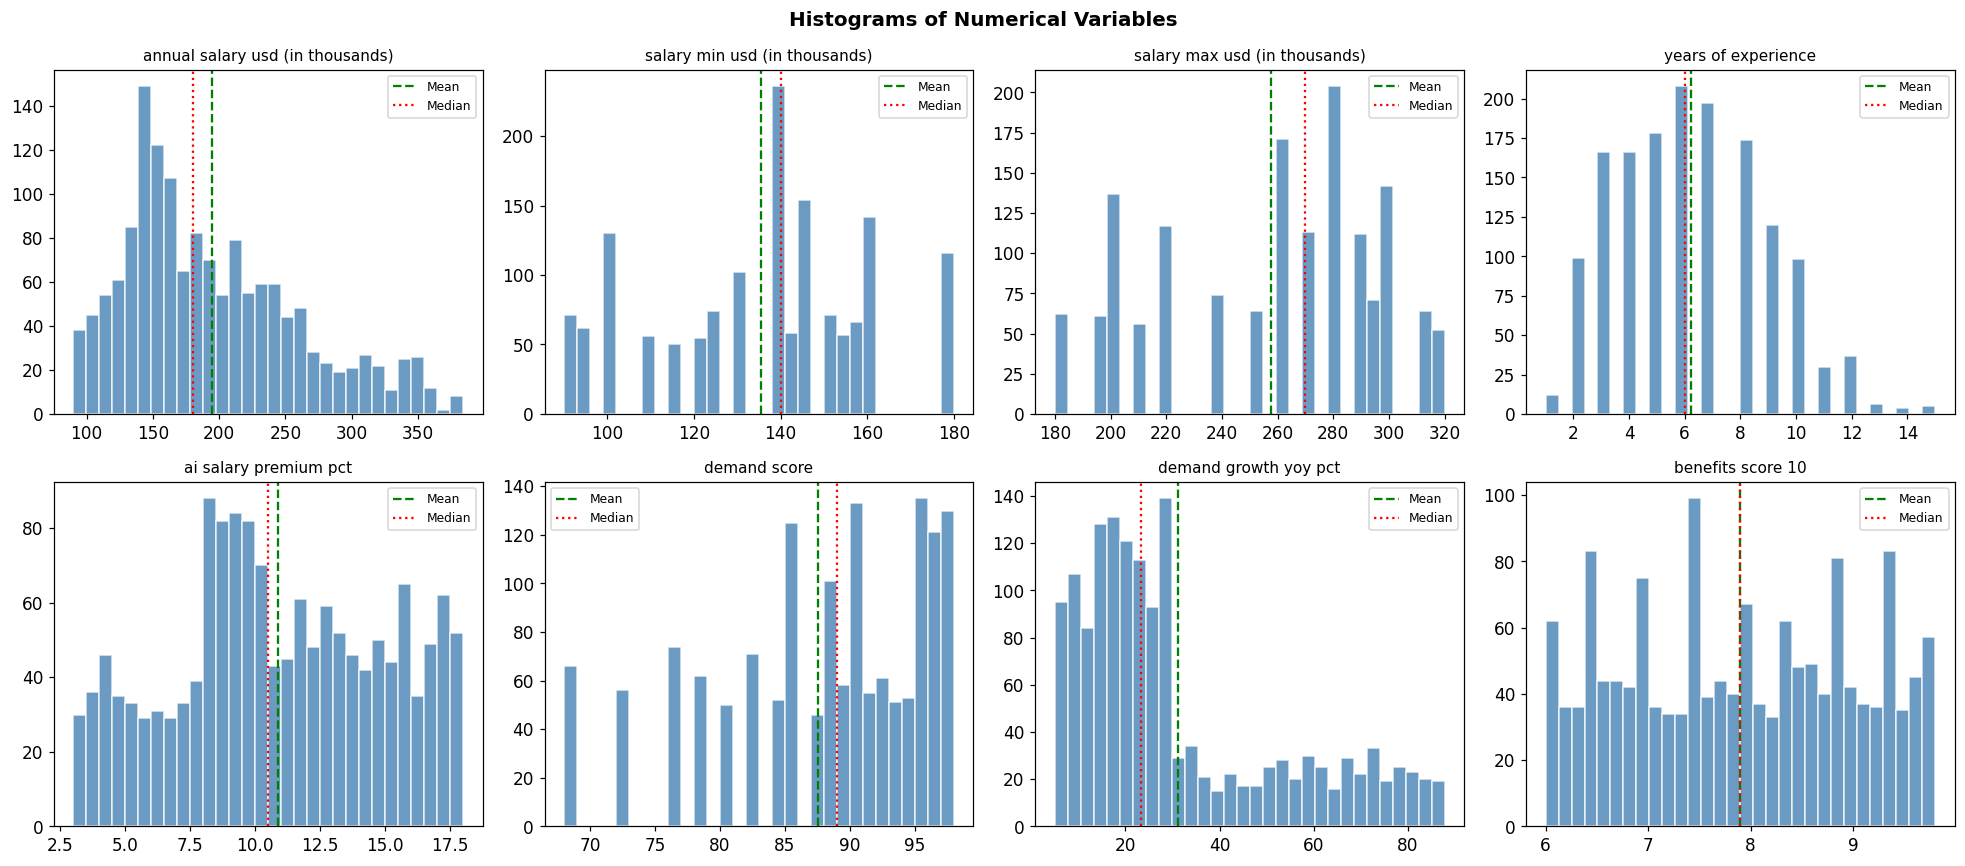

In [7]:
# 2.3 Histograms
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    titulo_ext = ""
    
    if i in range(3):
        data = data / 1000
        titulo_ext = " (in thousands)"
    
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(), color='green', linestyle='--', lw=1.5, label='Mean')
    axes[i].axvline(data.median(), color='red', linestyle=':', lw=1.5, label='Median')
    axes[i].set_title(col.replace('_', ' ') + titulo_ext, fontsize=10)
    axes[i].legend(fontsize=8)

fig.suptitle('Histograms of Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

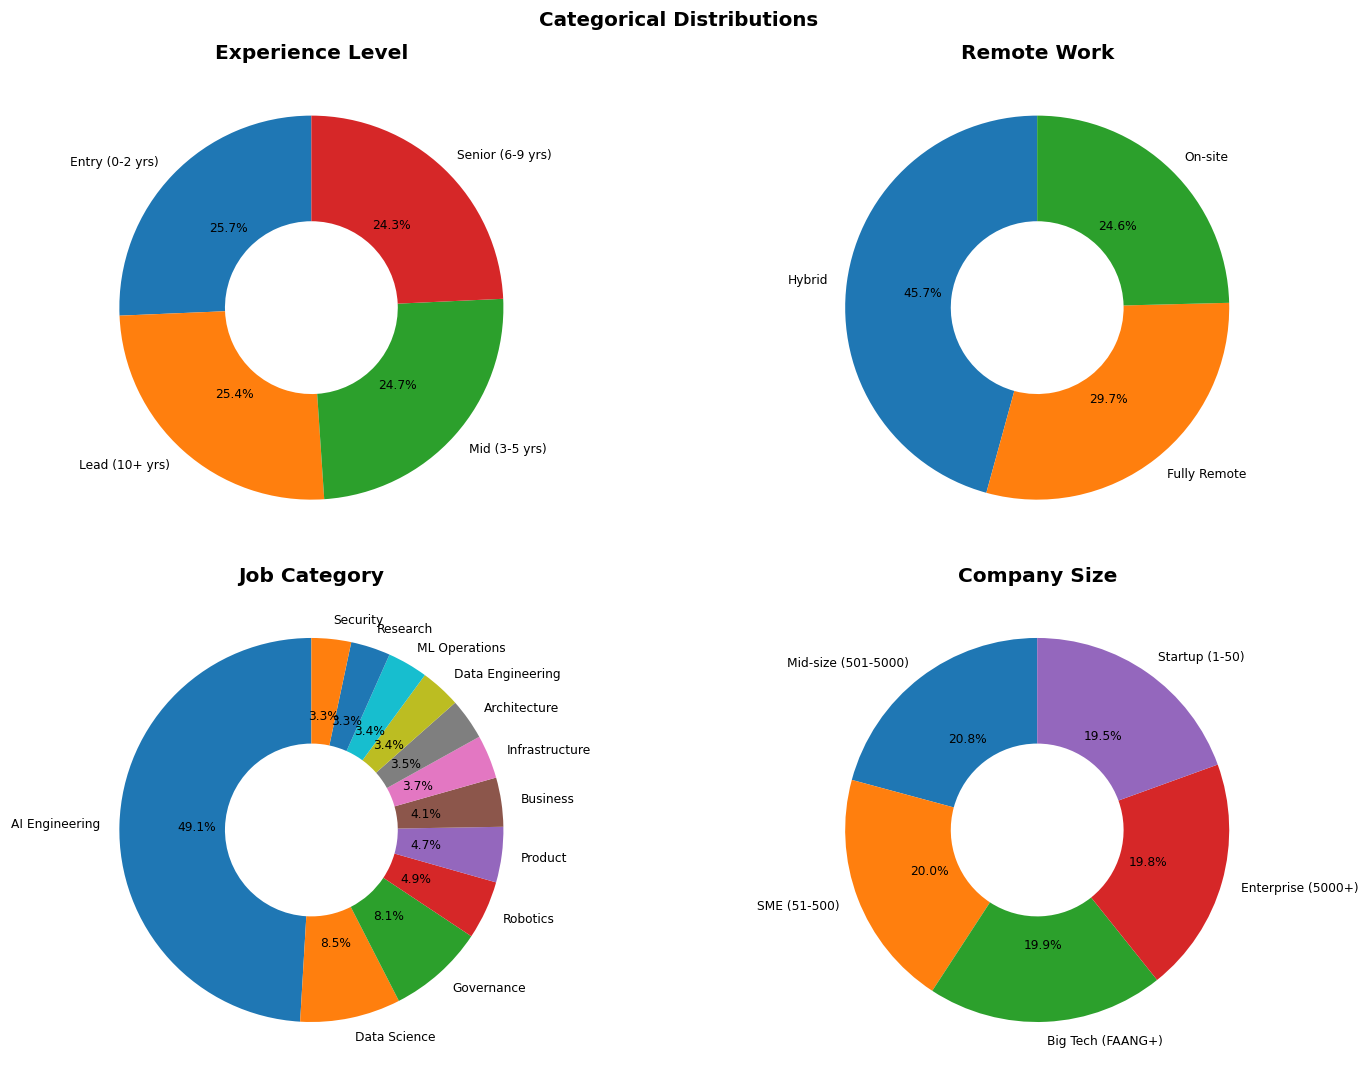

In [8]:
# 2.4 Pie charts — categorical distributions
pie_cols = ['experience_level', 'remote_work', 'job_category', 'company_size']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, pie_cols):
    counts = df[col].value_counts()
    wedge_props = dict(width=0.55)
    
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           startangle=90, wedgeprops=wedge_props,
           textprops={'fontsize': 8})
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')

fig.suptitle('Categorical Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

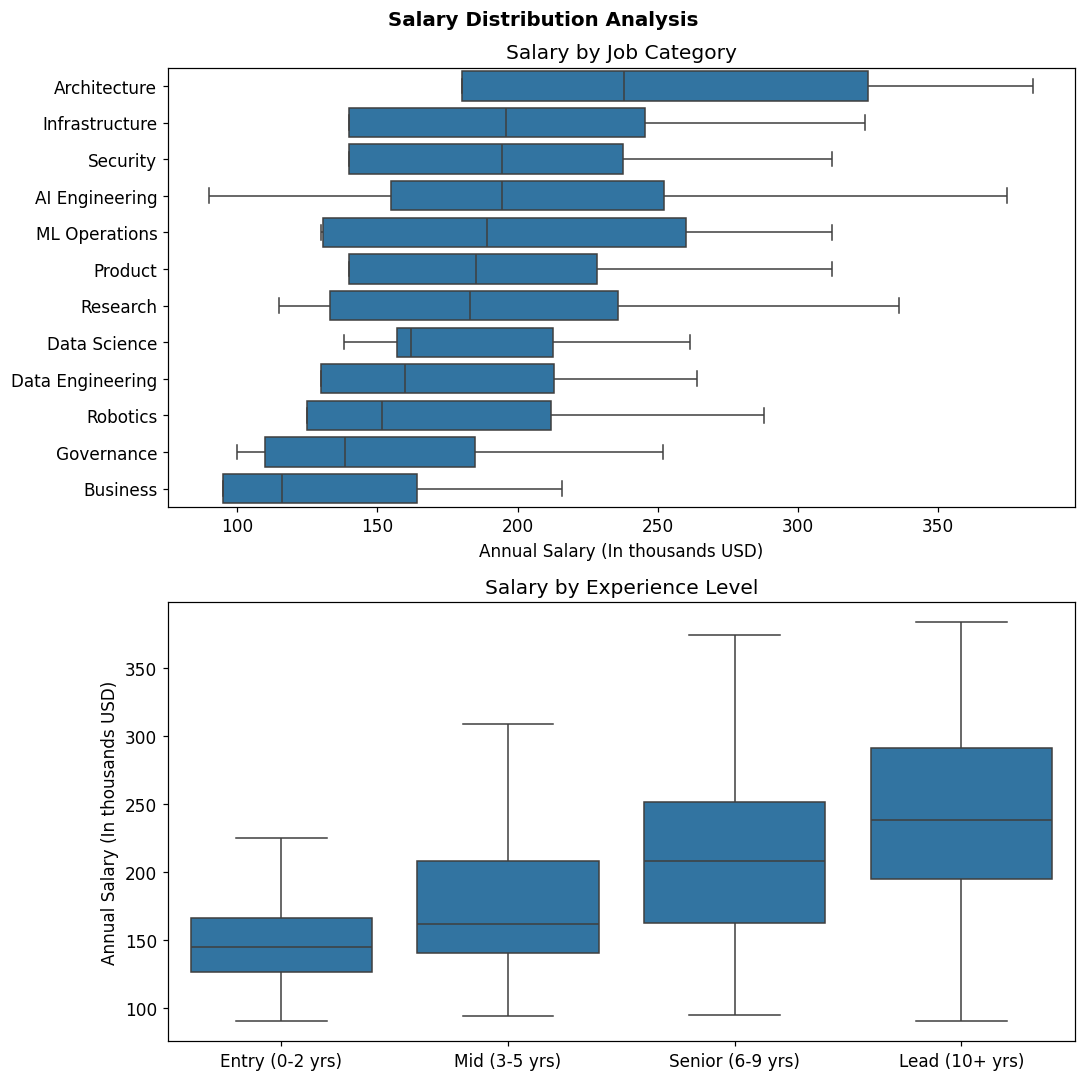

In [9]:
# 2.5 Salary distribution by category & experience

# Cambiado a 2 filas, 1 columna y ajustado el tamaño (figsize) para apilado vertical
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

df_scaled = df.copy()
df_scaled['annual_salary_usd'] = df_scaled['annual_salary_usd'] / 1000

# Box by job_category (Primer gráfico - Arriba)
order_cat = df_scaled.groupby('job_category')['annual_salary_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df_scaled, y='job_category', x='annual_salary_usd', order=order_cat, ax=axes[0])
axes[0].set_title('Salary by Job Category')
axes[0].set_xlabel('Annual Salary (In thousands USD)')
axes[0].set_ylabel('')

# Box by experience level (Segundo gráfico - Abajo)
exp_order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)']
sns.boxplot(data=df_scaled, x='experience_level', y='annual_salary_usd', order=exp_order, ax=axes[1], showfliers=False)
axes[1].set_title('Salary by Experience Level')
axes[1].set_xlabel('')
axes[1].set_ylabel('Annual Salary (In thousands USD)')

# Se añade 'y=0.98' al título general para que no se solape con el gráfico de arriba
plt.suptitle('Salary Distribution Analysis', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

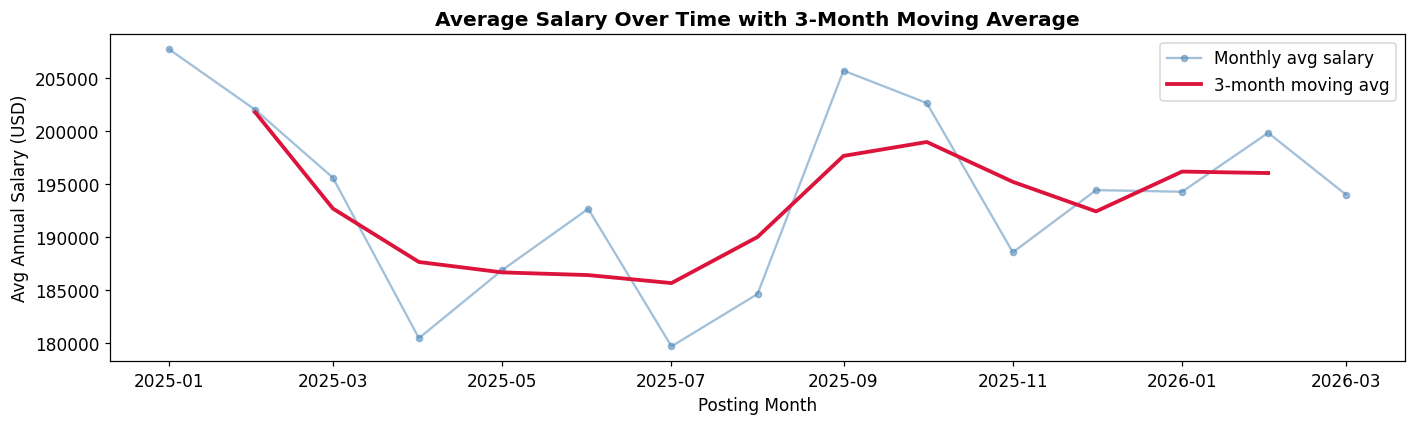

In [10]:
# 2.6 Time series — Moving average of salary by posting month
df_ts = df.copy()
df_ts['year_month'] = pd.to_datetime(
    df_ts['posting_year'].astype(str) + '-' + df_ts['posting_month'].astype(str).str.zfill(2)
)
monthly_salary = df_ts.groupby('year_month')['annual_salary_usd'].mean().sort_index()
ma3 = monthly_salary.rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly_salary.index, monthly_salary.values, color='steelblue', alpha=0.5,
        marker='o', ms=4, label='Monthly avg salary')
ax.plot(ma3.index, ma3.values, color='crimson', lw=2.5, label='3-month moving avg')
ax.set_title('Average Salary Over Time with 3-Month Moving Average', fontweight='bold')
ax.set_xlabel('Posting Month')
ax.set_ylabel('Avg Annual Salary (USD)')
ax.legend()
plt.tight_layout()
plt.show()

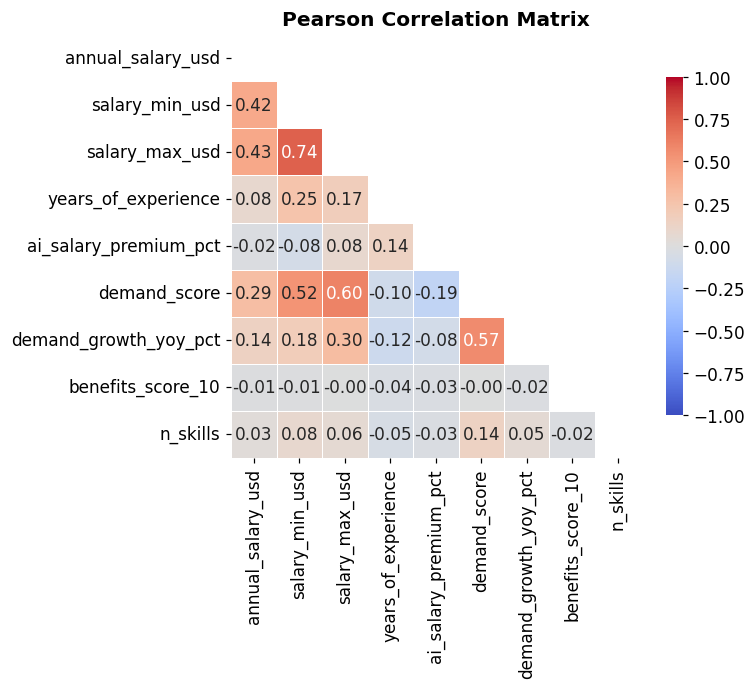

In [11]:
# 2.7 Pearson Correlation Matrix
corr_df = df[num_cols + ['n_skills']].dropna()
corr_mat = corr_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, cbar_kws={"shrink": .8})

ax.set_title('Pearson Correlation Matrix', fontweight='bold')
plt.show()

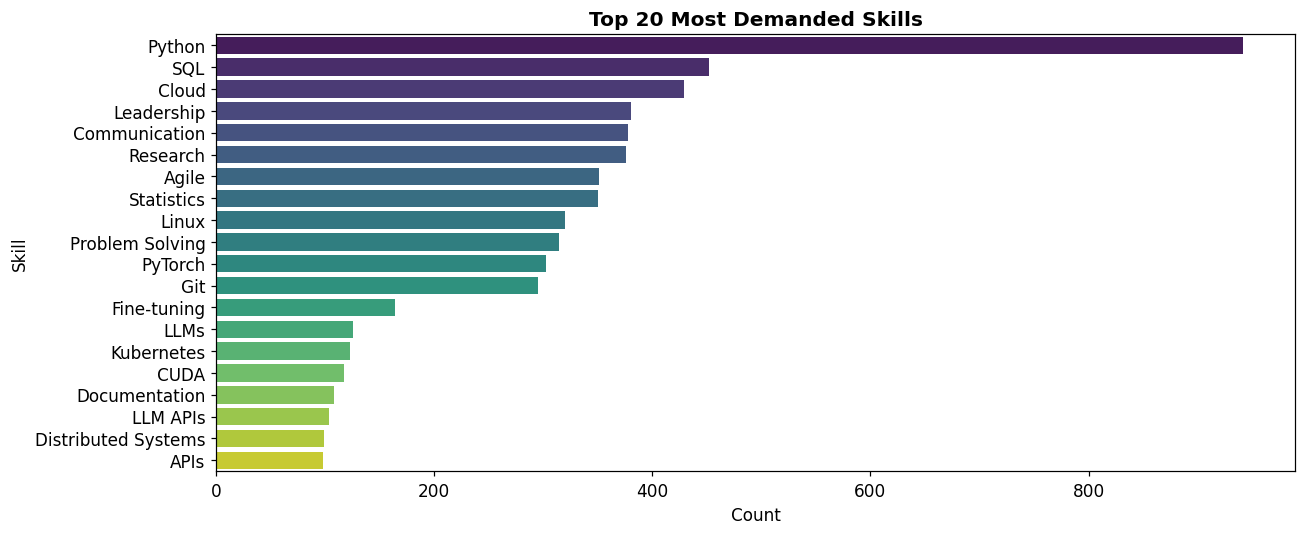

In [12]:
# 2.8 Top skills by frequency
all_skills = [skill for skills in df['skills_list'] for skill in skills]
skill_counts = Counter(all_skills).most_common(20)

skills_df = pd.DataFrame(skill_counts, columns=['Skill', 'Count'])
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=skills_df, y='Skill', x='Count', palette='viridis', ax=ax)
ax.set_title('Top 20 Most Demanded Skills', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. PRINCIPAL COMPONENT ANALYSIS (PCA)

In [13]:
# 3.1 Feature selection & normalisation
pca_features = ['annual_salary_usd', 'years_of_experience', 'demand_score',
                'ai_salary_premium_pct', 'benefits_score_10']

df_pca = df[pca_features + ['job_category']].dropna()
X_pca = df_pca[pca_features].values

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_pca)
print(f'PCA input shape: {X_scaled.shape}')

PCA input shape: (1500, 5)


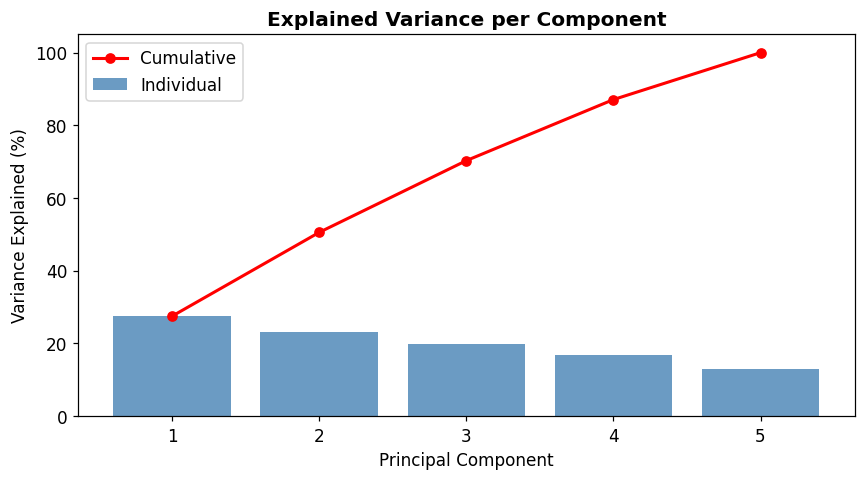

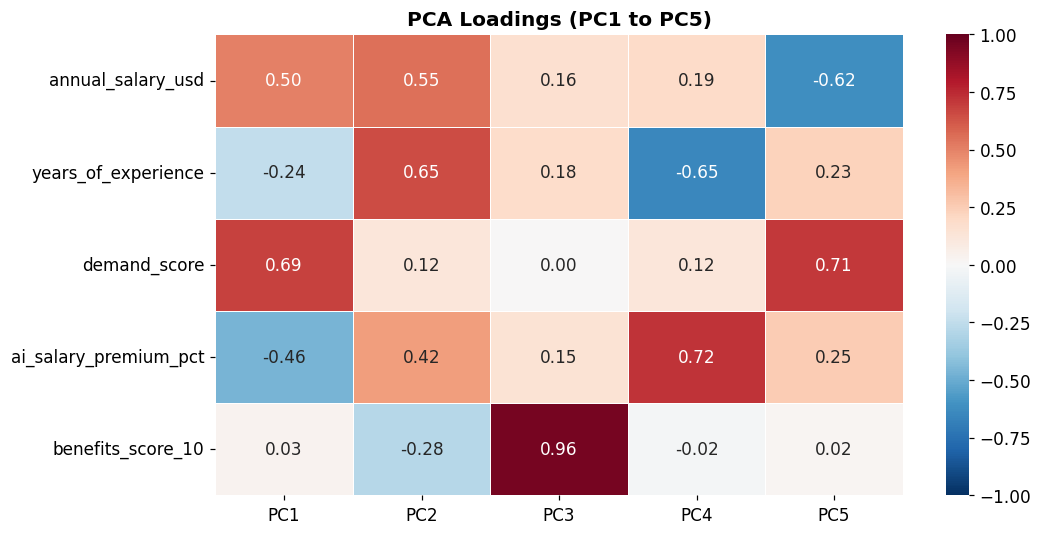

PC1 explains 27.5% | PC2 explains 23.0%
Combined PC1+PC2: 50.6%


In [14]:
# 3.2 Fit PCA & explained variance
pca = PCA(n_components=5, random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X_scaled)

exp_var = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(exp_var)

fig1, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(range(1, 6), exp_var, color='steelblue', alpha=0.8, label='Individual')
ax1.plot(range(1, 6), cum_var, 'r-o', lw=2, label='Cumulative')
# Se ha eliminado la línea horizontal del 80% que estaba aquí
ax1.set_title('Explained Variance per Component', fontweight='bold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.legend()
plt.tight_layout()
plt.show()

# Loadings heatmap
loadings = pd.DataFrame(pca.components_.T,
                        index=pca_features,
                        columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

fig2, ax2 = plt.subplots(figsize=(10, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', ax=ax2,
            vmin=-1, vmax=1, linewidths=0.5)
ax2.set_title('PCA Loadings (PC1 to PC5)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PC1 explains {exp_var[0]:.1f}% | PC2 explains {exp_var[1]:.1f}%')
print(f'Combined PC1+PC2: {cum_var[1]:.1f}%')

### 3.3 Interactive 3D PCA Visualization

> **NOTE FOR GITHUB VIEWERS:** This cell generates a fully interactive 3D visualization built with Plotly and ipywidgets. GitHub does not render interactive widgets, so this section will appear blank in the static preview.
>
> To explore the visualization, **download the notebook and run it locally** in JupyterLab or Jupyter Notebook (with `plotly` and `ipywidgets` installed). A walkthrough video is also available on YouTube.


In [15]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
import matplotlib.colors as mcolors
import threading
import time

df_plot = df_pca.copy()
df_plot['PC1'] = X_pca_full[:, 0]
df_plot['PC2'] = X_pca_full[:, 1]
df_plot['PC3'] = X_pca_full[:, 2]
df_plot['PC4'] = X_pca_full[:, 3]
df_plot['PC5'] = X_pca_full[:, 4]

categories = df_plot['job_category'].cat.categories.tolist()
sns_palette = sns.color_palette('tab20', n_colors=len(categories))
color_map = {cat: mcolors.to_hex(sns_palette[i]) for i, cat in enumerate(categories)}

pc1_min, pc1_max = float(df_plot['PC1'].min()), float(df_plot['PC1'].max())
pc2_min, pc2_max = float(df_plot['PC2'].min()), float(df_plot['PC2'].max())
pc3_min, pc3_max = float(df_plot['PC3'].min()), float(df_plot['PC3'].max())
pad_pc1 = (pc1_max - pc1_min) * 0.05
pad_pc2 = (pc2_max - pc2_min) * 0.05
pad_pc3 = (pc3_max - pc3_min) * 0.05

# CENTROIDES FINALES K-MEANS — coordenadas en espacio PCA (PC1..PC5)
C1_PCA = np.array([ 0.70663611, -0.07000566, -0.04733432,  0.08309252,  0.20438087])
C2_PCA = np.array([-2.1366486,  -0.15910704, -0.00061352, -0.33545010, -0.94306170])

fig_3d = go.FigureWidget()

for cat in categories:
    mask = df_plot['job_category'] == cat
    df_cat = df_plot[mask]
    fig_3d.add_trace(go.Scatter3d(
        x=df_cat['PC1'],
        y=df_cat['PC2'],
        z=df_cat['PC3'],
        mode='markers',
        name=cat,
        marker=dict(
            size=5,
            color=color_map[cat],
            opacity=0.7,
            line=dict(width=0.5, color='White')
        )
    ))

# Centroides k-means
C1_PC4, C1_PC5 = C1_PCA[3], C1_PCA[4]
C2_PC4, C2_PC5 = C2_PCA[3], C2_PCA[4]

fig_3d.add_trace(go.Scatter3d(
    x=[C1_PCA[0]], y=[C1_PCA[1]], z=[C1_PCA[2]],
    mode='markers+text',
    name='Centroid — AI Engineering',
    text=['C1 (AI Eng)'],
    textposition='top center',
    marker=dict(color='crimson', size=10, symbol='diamond',
                line=dict(width=1.5, color='white')),
    visible=True
))

fig_3d.add_trace(go.Scatter3d(
    x=[C2_PCA[0]], y=[C2_PCA[1]], z=[C2_PCA[2]],
    mode='markers+text',
    name='Centroid — Governance',
    text=['C2 (Gov)'],
    textposition='top center',
    marker=dict(color='royalblue', size=10, symbol='diamond',
                line=dict(width=1.5, color='white')),
    visible=True
))

# Plano separador entre los dos centroides
_mid   = (C1_PCA[:3] + C2_PCA[:3]) / 2.0
_nv    = C2_PCA[:3] - C1_PCA[:3]
_A, _B, _C = _nv
_D     = np.dot(_nv, _mid)
_px    = np.linspace(pc1_min - pad_pc1, pc1_max + pad_pc1, 20)
_py    = np.linspace(pc2_min - pad_pc2, pc2_max + pad_pc2, 20)
_pX, _pY = np.meshgrid(_px, _py)
_Csafe = _C if abs(_C) > 1e-6 else 1e-6
_pZ    = (_D - _A * _pX - _B * _pY) / _Csafe

fig_3d.add_trace(go.Surface(
    x=_pX, y=_pY, z=_pZ,
    colorscale=[[0, 'black'], [1, 'black']],
    opacity=0.18,
    showscale=False,
    name='Decision Boundary',
    visible=True
))

CENTROID_TRACE_IDX   = len(categories)      # índice traza C1
GOVERNANCE_TRACE_IDX = len(categories) + 1  # índice traza C2
PLANE_TRACE_IDX      = len(categories) + 2  # índice traza plano

fig_3d.update_layout(
    width=750, height=600,
    title='<b>3D PCA — Interactive Slicing through PC4 and PC5</b>',
    scene=dict(
        xaxis=dict(title=f'PC1 ({exp_var[0]:.1f}%)', range=[pc1_min - pad_pc1, pc1_max + pad_pc1]),
        yaxis=dict(title=f'PC2 ({exp_var[1]:.1f}%)', range=[pc2_min - pad_pc2, pc2_max + pad_pc2]),
        zaxis=dict(title=f'PC3 ({exp_var[2]:.1f}%)', range=[pc3_min - pad_pc3, pc3_max + pad_pc3]),
        aspectmode='cube'
    ),
    legend_title_text='Job Category',
    margin=dict(l=0, r=0, b=0, t=50)
)

pc4_min, pc4_max = float(df_plot['PC4'].min()), float(df_plot['PC4'].max())
pc5_min, pc5_max = float(df_plot['PC5'].min()), float(df_plot['PC5'].max())
pad_pc4 = (pc4_max - pc4_min) * 0.05
pad_pc5 = (pc5_max - pc5_min) * 0.05

t_pc4 = (pc4_min + pc4_max) / 2
t_pc5 = (pc5_min + pc5_max) / 2
state = {'pc4': t_pc4, 'pc5': t_pc5, 'locked': False, 'filter_two_cats': False, 'show_plane': False}

grid_x, grid_y = np.linspace(pc4_min, pc4_max, 50), np.linspace(pc5_min, pc5_max, 50)
mesh_x, mesh_y = np.meshgrid(grid_x, grid_y)

fig_2d = go.FigureWidget()
fig_2d.add_trace(go.Scatter(
    x=mesh_x.flatten(), y=mesh_y.flatten(),
    mode='markers', name='Touchpad',
    marker=dict(color='rgba(0,0,0,0)', size=25),
    hoverinfo='text', text=[''] * len(mesh_x.flatten()),
    hoverlabel=dict(bgcolor='rgba(0,0,0,0)', bordercolor='rgba(0,0,0,0)')
))

fig_2d.add_trace(go.Scatter(
    x=[t_pc4], y=[t_pc5],
    mode='markers', name='Selector',
    marker=dict(color='red', size=12, symbol='circle'),
    hoverinfo='none'
))

fig_2d.update_layout(
    width=400, height=400,
    title='<b>2D Panel (Mode: SCANNER)</b><br>Click anywhere to lock the position',
    xaxis=dict(title='PC4', range=[pc4_min - pad_pc4, pc4_max + pad_pc4], fixedrange=True),
    yaxis=dict(title='PC5', range=[pc5_min - pad_pc5, pc5_max + pad_pc5], fixedrange=True),
    dragmode=False, showlegend=False,
    margin=dict(l=40, r=20, b=40, t=60)
)

slider_d = widgets.FloatSlider(value=1.0, min=0.2, max=2.0, step=0.1, description='Distance d:')
btn_rotate = widgets.Button(description='Start Rotation', button_style='success', icon='play')
btn_filter_cats = widgets.Button(description='Filter: Eng & Gov Only', button_style='info', icon='filter', layout=widgets.Layout(margin='10px 0px 0px 0px'))

# Modificado para reflejar que ahora también controla los centroides
btn_plane = widgets.Button(
    description='Show Separating Plane',
    button_style='', 
    icon='window-maximize',
    layout=widgets.Layout(margin='10px 0px 0px 0px')
)

class MapRotator:
    def __init__(self, fig):
        self.fig = fig
        self.thread = None
        self.running = False
        self.angle_x = 0.0

    def start(self):
        if not self.running:
            self.running = True
            self.thread = threading.Thread(target=self._loop, daemon=True)
            self.thread.start()

    def stop(self):
        self.running = False
        if self.thread:
            self.thread.join(timeout=0.2)

    def _loop(self):
        r = 1.6
        while self.running:
            self.angle_x += 0.02 + np.random.uniform(-0.004, 0.004)
            angle_y = 1.0 + 0.25 * np.sin(self.angle_x * 0.4) + np.random.uniform(-0.005, 0.005)
            x = r * np.cos(self.angle_x) * np.sin(angle_y)
            y = r * np.sin(self.angle_x) * np.sin(angle_y)
            z = r * np.cos(angle_y)
            try:
                self.fig.layout.scene.camera.eye = dict(x=x, y=y, z=z)
            except:
                break
            time.sleep(0.04)

rotator = MapRotator(fig_3d)

# FUNCIÓN CENTRAL DE ACTUALIZACIÓN
def update_plot():
    pc4_target = state['pc4']
    pc5_target = state['pc5']
    d_threshold = slider_d.value
    
    distances = np.sqrt((df_plot['PC4'] - pc4_target)**2 + (df_plot['PC5'] - pc5_target)**2)
    mask_global = distances <= d_threshold
    
    dist_c1 = np.sqrt((C1_PC4 - pc4_target)**2 + (C1_PC5 - pc5_target)**2)
    dist_c2 = np.sqrt((C2_PC4 - pc4_target)**2 + (C2_PC5 - pc5_target)**2)
    
    with fig_3d.batch_update():
        for i, cat in enumerate(categories):
            trace = fig_3d.data[i]
            if state['filter_two_cats'] and cat not in ['AI Engineering', 'Governance']:
                trace.x, trace.y, trace.z = [], [], []
            else:
                mask_cat = (df_plot['job_category'] == cat) & mask_global
                df_sub = df_plot[mask_cat]
                trace.x = df_sub['PC1']
                trace.y = df_sub['PC2']
                trace.z = df_sub['PC3']
        
        # NUEVA LÓGICA: Los centroides y el plano ahora dependen estrictamente de state['show_plane']
        c1_visible = bool(dist_c1 <= d_threshold) and state['show_plane']
        c2_visible = bool(dist_c2 <= d_threshold) and state['show_plane']
        plane_visible = (c1_visible or c2_visible) and state['show_plane']
        
        fig_3d.data[CENTROID_TRACE_IDX].visible   = c1_visible
        fig_3d.data[GOVERNANCE_TRACE_IDX].visible = c2_visible
        fig_3d.data[PLANE_TRACE_IDX].visible      = plane_visible

def on_hover_2d(trace, points, selector):
    if state['locked'] or not points.point_inds:
        return
    idx = points.point_inds[0]
    state['pc4'] = trace.x[idx]
    state['pc5'] = trace.y[idx]
    update_plot()

def on_click_2d(trace, points, selector):
    if not points.point_inds:
        return
    state['locked'] = not state['locked']
    idx = points.point_inds[0]
    state['pc4'] = trace.x[idx]
    state['pc5'] = trace.y[idx]
    
    with fig_2d.batch_update():
        fig_2d.data[1].x = [state['pc4']]
        fig_2d.data[1].y = [state['pc5']]
        if state['locked']:
            fig_2d.data[1].marker.color = 'blue'
            fig_2d.layout.title.text = '<b>2D Panel (Mode: FROZEN)</b><br>Click to release the scanner'
        else:
            fig_2d.data[1].marker.color = 'red'
            fig_2d.layout.title.text = '<b>2D Panel (Mode: SCANNER)</b><br>Click to lock the position'
            
    update_plot()

def on_btn_rotate_clicked(b):
    if rotator.running:
        rotator.stop()
        btn_rotate.description = 'Start Rotation'
        btn_rotate.button_style = 'success'
        btn_rotate.icon = 'play'
    else:
        rotator.start()
        btn_rotate.description = 'Stop Rotation'
        btn_rotate.button_style = 'danger'
        btn_rotate.icon = 'stop'

def on_btn_filter_cats_clicked(b):
    state['filter_two_cats'] = not state['filter_two_cats']
    if state['filter_two_cats']:
        btn_filter_cats.description = 'Show All Categories'
        btn_filter_cats.button_style = 'warning'
        btn_filter_cats.icon = 'th-list'
    else:
        btn_filter_cats.description = 'Filter: Eng & Gov Only'
        btn_filter_cats.button_style = 'info'
        btn_filter_cats.icon = 'filter'
    update_plot()

# INTERRUPTOR DEL BOTÓN CORREGIDO
def on_btn_plane_clicked(b):
    state['show_plane'] = not state['show_plane']
    if state['show_plane']:
        btn_plane.description = 'Hide Plane & Centroids'
        btn_plane.button_style = 'warning'
    else:
        btn_plane.description = 'Show Separating Plane'
        btn_plane.button_style = ''
    
    # Llamamos a la función central para que actualice la visibilidad de todo a la vez
    update_plot()

fig_2d.data[0].on_hover(on_hover_2d)
fig_2d.data[0].on_click(on_click_2d)
btn_rotate.on_click(on_btn_rotate_clicked)
btn_filter_cats.on_click(on_btn_filter_cats_clicked)
btn_plane.on_click(on_btn_plane_clicked)

def on_slider_change(change):
    update_plot()

slider_d.observe(on_slider_change, names='value')

update_plot()

panel_controles = widgets.VBox([
    fig_2d,
    slider_d,
    btn_rotate,
    btn_filter_cats,
    btn_plane
])

dashboard = widgets.HBox([fig_3d, panel_controles])
display(dashboard)

    'data': [{'marker': {'color': '#1f77b4', 'line': {'color': 'White', 'width':…

## 4. K-MEANS CLUSTERING (AI ENGINEERING & GOVERNANCE)


In [16]:
# 4.1  Filter dataset to AI Engineering & Governance only
# Reuse the scaler and features from Section 3 (scaler_pca, pca_features, df_pca, X_scaled)

mask_km = df_pca['job_category'].isin(['AI Engineering', 'Governance'])
X_km     = X_scaled[mask_km]                       # standardised feature matrix
labels_km = df_pca['job_category'][mask_km].values  # true category labels

print(f"Points selected  : {len(X_km)}")
print(f"  AI Engineering : {(labels_km == 'AI Engineering').sum()}")
print(f"  Governance     : {(labels_km == 'Governance').sum()}")


Points selected  : 858
  AI Engineering : 736
  Governance     : 122


In [17]:
# 4.2  K-Means (k=2) — manual implementation
# Centroid 1 ← cluster for AI Engineering
# Centroid 2 ← cluster for Governance
#
# Los centroides iniciales se especifican en el espacio PCA (las coordenadas
# que corresponden a posiciones en el mapa con bases de vectores propios):
c1_pca_init = np.array([ 1.0, 0.0, 0.0, 0.0, 0.0])
c2_pca_init = np.array([-3.0, 0.0, 0.0, 0.0, 0.0])

# Paso 1 — Invertir la proyección PCA para obtener las coordenadas en el espacio
# escalado estándar (el mismo espacio de X_km). pca.inverse_transform devuelve:
#   X_scaled ≈ c_pca @ pca.components_
# Este es el espacio donde se computan las distancias euclidianas en k-means.
c1 = pca.inverse_transform(c1_pca_init.reshape(1, -1)).flatten()
c2 = pca.inverse_transform(c2_pca_init.reshape(1, -1)).flatten()

print("Centroides iniciales en espacio PCA:")
print(f"  C1_pca = {c1_pca_init}")
print(f"  C2_pca = {c2_pca_init}")
print()
print("Centroides iniciales traducidos al espacio escalado estándar (X_km):")
print(f"  C1_scaled = {np.round(c1, 6)}")
print(f"  C2_scaled = {np.round(c2, 6)}")
print()

# Paso 2 — K-Means en el espacio escalado estándar
CONVERGENCE_THRESHOLD = 0.05
history = []
iteration = 0

while True:
    # Assignment step — distancia euclídea a cada centroide (en espacio escalado)
    d1 = np.linalg.norm(X_km - c1, axis=1)
    d2 = np.linalg.norm(X_km - c2, axis=1)
    assignments = (d2 < d1).astype(int)  # 0 → Centroide 1, 1 → Centroide 2

    # Update step — nuevo centroide = media de los puntos asignados
    c1_new = X_km[assignments == 0].mean(axis=0) if (assignments == 0).sum() > 0 else c1.copy()
    c2_new = X_km[assignments == 1].mean(axis=0) if (assignments == 1).sum() > 0 else c2.copy()

    disp1 = np.linalg.norm(c1_new - c1)
    disp2 = np.linalg.norm(c2_new - c2)
    iteration += 1
    history.append((iteration, disp1, disp2))
    print(f"Iter {iteration:>2d}  |  disp(C1)={disp1:.6f}  |  disp(C2)={disp2:.6f}")

    c1, c2 = c1_new, c2_new

    if disp1 < CONVERGENCE_THRESHOLD and disp2 < CONVERGENCE_THRESHOLD:
        print(f"\n✓ Converged after {iteration} iterations (both displacements < {CONVERGENCE_THRESHOLD})")
        break

print(f"\nCentroide final 1 (AI Engineering) — espacio escalado:")
print(f"  {np.round(c1, 6)}")
print(f"\nCentroide final 2 (Governance) — espacio escalado:")
print(f"  {np.round(c2, 6)}")

# Paso 3 — Proyectar los centroides finales de vuelta al espacio PCA
# para que las coordenadas sean interpretables en el mapa 5D con bases PCA.
c1_pca_final = pca.transform(c1.reshape(1, -1)).flatten()
c2_pca_final = pca.transform(c2.reshape(1, -1)).flatten()

print()
print("CENTROIDES FINALES EN EL ESPACIO PCA (coordenadas para el mapa)")
print(f"  C1_pca (AI Engineering): {np.round(c1_pca_final, 8)}")
print(f"  C2_pca (Governance)    : {np.round(c2_pca_final, 8)}")


Centroides iniciales en espacio PCA:
  C1_pca = [1. 0. 0. 0. 0.]
  C2_pca = [-3.  0.  0.  0.  0.]

Centroides iniciales traducidos al espacio escalado estándar (X_km):
  C1_scaled = [ 0.503521 -0.243948  0.685945 -0.464065  0.032842]
  C2_scaled = [-1.510564  0.731845 -2.057835  1.392195 -0.098525]

Iter  1  |  disp(C1)=0.374910  |  disp(C2)=1.286313
Iter  2  |  disp(C1)=0.011844  |  disp(C2)=0.052203
Iter  3  |  disp(C1)=0.000000  |  disp(C2)=0.000000

✓ Converged after 3 iterations (both displacements < 0.05)

Centroide final 1 (AI Engineering) — espacio escalado:
  [ 1.99307e-01 -2.33900e-01  6.30340e-01 -2.51776e-01  7.40000e-05]

Centroide final 2 (Governance) — espacio escalado:
  [-0.645019  0.4178   -2.192069  0.441866 -0.03814 ]

CENTROIDES FINALES EN EL ESPACIO PCA (coordenadas para el mapa)
  C1_pca (AI Engineering): [ 0.70663611 -0.07000566 -0.04733432  0.08309252  0.20438087]
  C2_pca (Governance)    : [-2.1366486e+00 -1.5910704e-01 -6.1352000e-04 -3.3545010e-01
 -9.430617

In [18]:
# 4.3  Final assignment & verification
d1_final = np.linalg.norm(X_km - c1, axis=1)
d2_final = np.linalg.norm(X_km - c2, axis=1)
pred_labels = (d2_final < d1_final).astype(int)  # 0 → C1, 1 → C2

c1_cats = labels_km[pred_labels == 0]
c2_cats = labels_km[pred_labels == 1]

print("Cluster composition")
print(f"Centroid 1 — {(pred_labels==0).sum()} points  "
      f"(AI Eng: {(c1_cats=='AI Engineering').sum()}, "
      f"Gov: {(c1_cats=='Governance').sum()})")
print(f"Centroid 2 — {(pred_labels==1).sum()} points  "
      f"(AI Eng: {(c2_cats=='AI Engineering').sum()}, "
      f"Gov: {(c2_cats=='Governance').sum()})")



=== Cluster composition ===
Centroid 1 — 735 points  (AI Eng: 735, Gov: 0)
Centroid 2 — 123 points  (AI Eng: 1, Gov: 122)


In [19]:
# 4.4  Rand Index
# Ground truth: AI Engineering → 0, Governance → 1
true_labels = (labels_km == 'Governance').astype(int)

n = len(true_labels)
TP = TN = FP = FN = 0

for i in range(n):
    for j in range(i + 1, n):
        same_true = (true_labels[i] == true_labels[j])
        same_pred = (pred_labels[i] == pred_labels[j])
        if same_true and same_pred:
            TP += 1
        elif not same_true and not same_pred:
            TN += 1
        elif not same_true and same_pred:
            FP += 1
        else:  # same_true and not same_pred
            FN += 1

rand_index = (TP + TN) / (TP + TN + FP + FN)

print("Rand Index")
print(f"  TP = {TP:>7,}  (same cluster, same true label)")
print(f"  TN = {TN:>7,}  (different cluster, different true label)")
print(f"  FP = {FP:>7,}  (same cluster, different true label)")
print(f"  FN = {FN:>7,}  (different cluster, same true label)")
print()
print(f"  Rand Index = (TP+TN)/(TP+TN+FP+FN) = ({TP}+{TN})/({TP+TN+FP+FN}) = {rand_index:.6f}")


=== Rand Index ===
  TP = 277,126  (same cluster, same true label)
  TN =  89,670  (different cluster, different true label)
  FP =     122  (same cluster, different true label)
  FN =     735  (different cluster, same true label)

  Rand Index = (TP+TN)/(TP+TN+FP+FN) = (277126+89670)/(367653) = 0.997669


## 5. KNN — SALARY ESTIMATION

In [20]:
knn_features = ['years_of_experience', 'demand_score', 'ai_salary_premium_pct',
                'benefits_score_10', 'n_skills', 'is_senior', 'is_remote_friendly',
                'is_llm_role']

# Encode categoricals
le_cat  = LabelEncoder()
le_exp  = LabelEncoder()
le_comp = LabelEncoder()

df_knn = df.dropna(subset=knn_features + ['annual_salary_usd']).copy()
df_knn['job_category_enc'] = le_cat.fit_transform(df_knn['job_category'])
df_knn['experience_enc']   = le_exp.fit_transform(df_knn['experience_level'])
df_knn['company_size_enc'] = le_comp.fit_transform(df_knn['company_size'])

feature_cols = knn_features + ['job_category_enc', 'experience_enc', 'company_size_enc']
X = df_knn[feature_cols].values
y = df_knn['annual_salary_usd'].values

scaler_knn = StandardScaler()
X_norm = scaler_knn.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 1200 samples | Test: 300 samples


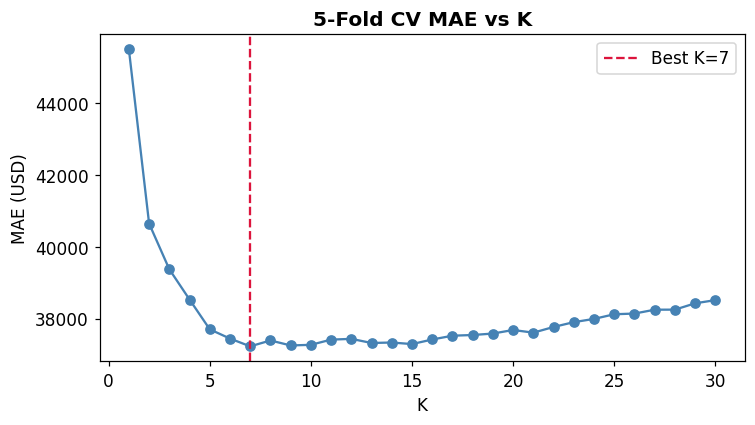

Optimal K = 7 | CV MAE = $37,230


In [21]:
k_range = range(1, 31)
mae_scores = [] # Se eliminó r2_scores

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance', metric='euclidean')
    cv_mae = -cross_val_score(knn, X_train, y_train, cv=5,
                               scoring='neg_mean_absolute_error').mean()
    mae_scores.append(cv_mae)

best_k = k_range[np.argmin(mae_scores)]

# Ajustado a un solo gráfico para MAE
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), mae_scores, 'o-', color='steelblue')
ax.axvline(best_k, color='crimson', linestyle='--', label=f'Best K={best_k}')
ax.set_title('5-Fold CV MAE vs K', fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('MAE (USD)')
ax.legend()

plt.tight_layout()
plt.show()
print(f'Optimal K = {best_k} | CV MAE = ${mae_scores[best_k-1]:,.0f}')

KNN Regression Results (K=7)
  MAE  : $39,241
  RMSE : $52,046


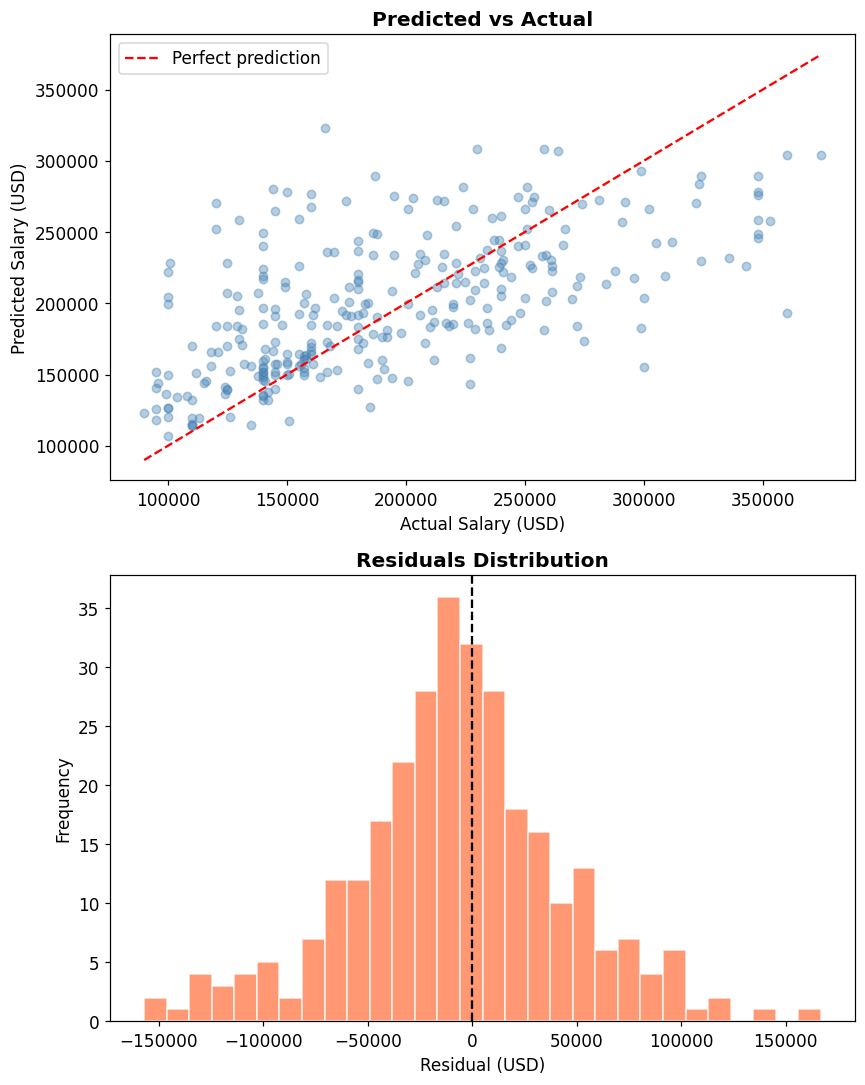

In [22]:
knn_final = KNeighborsRegressor(n_neighbors=best_k, weights='distance', metric='euclidean')
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'KNN Regression Results (K={best_k})')
print(f'  MAE  : ${mae:,.0f}')
print(f'  RMSE : ${rmse:,.0f}')

# Cambiado a 2 filas, 1 columna y ajustado el tamaño para apilado vertical
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Predicted vs Actual (Gráfico superior)
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=30)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].set_title('Predicted vs Actual', fontweight='bold')
axes[0].legend()

# Residuals (Gráfico inferior)
residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [23]:
def estimate_salary(years_exp, demand_sc, ai_premium, benefits, n_sk,
                    is_sen, is_remote, is_llm, cat, exp_level, comp_size):

    cat_enc  = le_cat.transform([cat])[0]   if cat in le_cat.classes_   else 0
    exp_enc  = le_exp.transform([exp_level])[0] if exp_level in le_exp.classes_ else 0
    comp_enc = le_comp.transform([comp_size])[0] if comp_size in le_comp.classes_ else 0

    row = np.array([[years_exp, demand_sc, ai_premium, benefits, n_sk,
                     is_sen, is_remote, is_llm, cat_enc, exp_enc, comp_enc]])
    row_norm = scaler_knn.transform(row)
    return knn_final.predict(row_norm)[0]

# Example predictions
examples = [
    dict(years_exp=2, demand_sc=75, ai_premium=5.0, benefits=6.5, n_sk=5,
         is_sen=0, is_remote=1, is_llm=0, cat='Data Science',
         exp_level='Entry (0-2 yrs)', comp_size='SME (51-500)'),
    dict(years_exp=8, demand_sc=95, ai_premium=12.0, benefits=8.0, n_sk=8,
         is_sen=1, is_remote=1, is_llm=1, cat='AI Engineering',
         exp_level='Senior (6-9 yrs)', comp_size='Big Tech (FAANG+)'),
    dict(years_exp=12, demand_sc=88, ai_premium=10.0, benefits=9.0, n_sk=10,
         is_sen=1, is_remote=0, is_llm=0, cat='Product',
         exp_level='Lead (10+ yrs)', comp_size='Enterprise (5000+)'),
]

print('Salary Estimation Demos')
for i, ex in enumerate(examples, 1):
    sal = estimate_salary(**ex)
    print(f'Profile {i} ({ex["exp_level"]}, {ex["cat"]}): ${sal:,.0f}')

=== Salary Estimation Demos ===
Profile 1 (Entry (0-2 yrs), Data Science): $123,128
Profile 2 (Senior (6-9 yrs), AI Engineering): $262,602
Profile 3 (Lead (10+ yrs), Product): $236,263
